In [7]:
#import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve
from scipy.interpolate import interp1d
import math

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'
#%matplotlib widget

colors = ['#3C536D', '#DAC746', '#6E6F6D', '#DC4D57']

In [8]:
data_background = np.loadtxt('../../output/one_k_00_background.dat')
data_cl_20 = np.loadtxt('../../output/one_k_00_cl.dat')

In [9]:
z = [data_background[i][0] for i in range(len(data_background))]
z = np.asarray(z)
H = [data_background[i][3] for i in range(len(data_background))]
H = np.asarray(H)
omega_vf = [data_background[i][15] for i in range(len(data_background))]
omega_vf = np.asarray(omega_vf)/H**2
#omega_vf_26 = [data_background_26[i][17] for i in range(len(data_background_26))]
#omega_vf_26 = np.exp(np.asarray(omega_vf_26))
a = 1/(1+z)

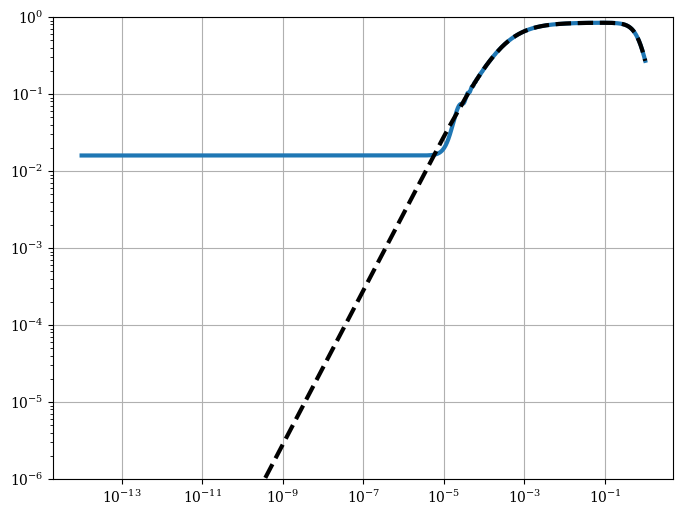

In [10]:
plt.figure(figsize=(8, 6))
plt.loglog(a, omega_vf, lw=3)
#plt.loglog(a, omega_vf_26, lw=3)
plt.loglog(a, H[-1]**2*0.26962/(H**2 *a**3), 'k--', lw=3)
plt.ylim(1.e-6, 1.e0)
plt.grid()

# One k    
## Tensor|

In [11]:
import glob, re

# pick which native-binary run to load: 'one_k' or 'one_k_tensor'
run = 'one_k'
prefix = f'../../output/{run}_00'

def load_pert(prefix):
    files = sorted(
        glob.glob(f'{prefix}_perturbations_k*_s.dat'),
        key=lambda p: int(re.search(r'_k(\d+)_s', p).group(1)),
    )
    data = [np.loadtxt(f) for f in files]
    ks = []
    for f in files:
        with open(f) as fh:
            ks.append(float(re.search(r'k\s*=\s*([\d.eE+-]+)', fh.readline()).group(1)))
    return data, ks

pert, k_vals = load_pert(prefix)

# 0-based columns (VFDM + svt_coupling): 1:a, 14:eta, 22:delta_cdm, 24:delta_vf, 25:theta_vf, 27:h_+, 28:d(h_+)
a_k      = [p[:, 1]  for p in pert]
h_plus   = [p[:, 27] for p in pert]
dh_plus  = [p[:, 28] for p in pert]

# LCDM companion run for overlays (same k_output_values assumed).
# LCDM scalar file has no VFDM columns: 1:a, 14:eta, 22:delta_cdm, 23:theta_cdm.
pert_lcdm, k_vals_lcdm = load_pert('../../output/one_k_lcdm_00')
a_k_lcdm = [p[:, 1] for p in pert_lcdm]

print(f'[{run}] {len(pert)} k modes: ' + ', '.join(f'{k:.3g}' for k in k_vals))
print(f'[lcdm] {len(pert_lcdm)} k modes: ' + ', '.join(f'{k:.3g}' for k in k_vals_lcdm))

[one_k] 2 k modes: 0.0001, 1
[lcdm] 2 k modes: 0.0001, 1


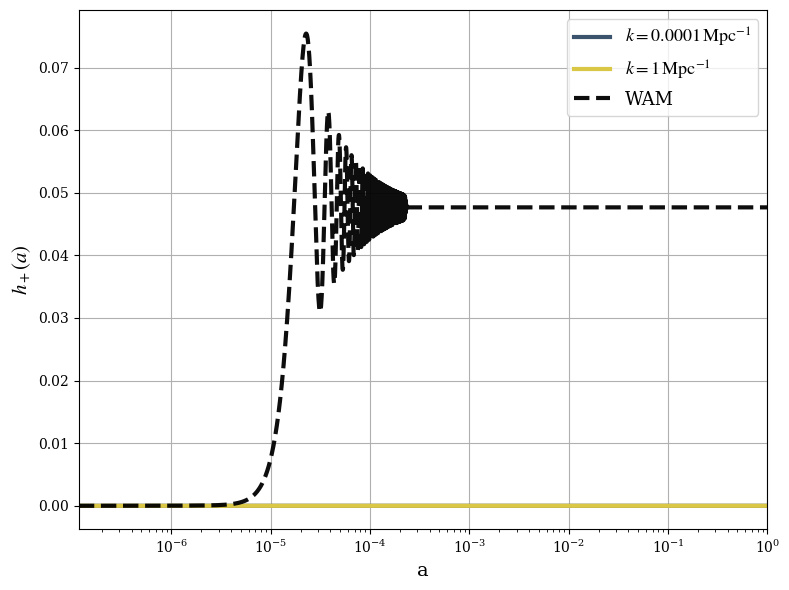

In [12]:
gammak  = np.pi/2
sigma_A = data_background[:, 21]   # sigma_A [1/Mpc]

# WAM reference (Weinberg adiabatic mode): h_+ ~ 3/4 sin^2(gamma_k) sigma_A / (aH)
# Interpolate the background-grid expression onto the lowest-k pert grid.
a_ref    = a_k[0]
weinberg = interp1d(a, 3./4. * np.sin(gammak)**2 * sigma_A / (H * a))(a_ref)
hp_ref   = h_plus[0]   # match the plotted (un-normalised) h_+ at its first sample

plt.figure(figsize=(8, 6))
for i in range(len(pert)):
    plt.plot(a_k[i], h_plus[i], color=colors[i % len(colors)], lw=3,
             label=rf'$k = {k_vals[i]:.2g}\,\mathrm{{Mpc}}^{{-1}}$')
plt.plot(a_ref, (hp_ref[0] - weinberg[0]) + weinberg, 'k--', lw=3, alpha=0.95, label='WAM')
plt.xscale('log')
plt.xlabel('a', size=14)
plt.ylabel(r'$h_+(a)$', size=15)
plt.xlim(min(a_k[0]), 1.e0)
plt.legend(fontsize=13)
plt.grid()
plt.tight_layout()

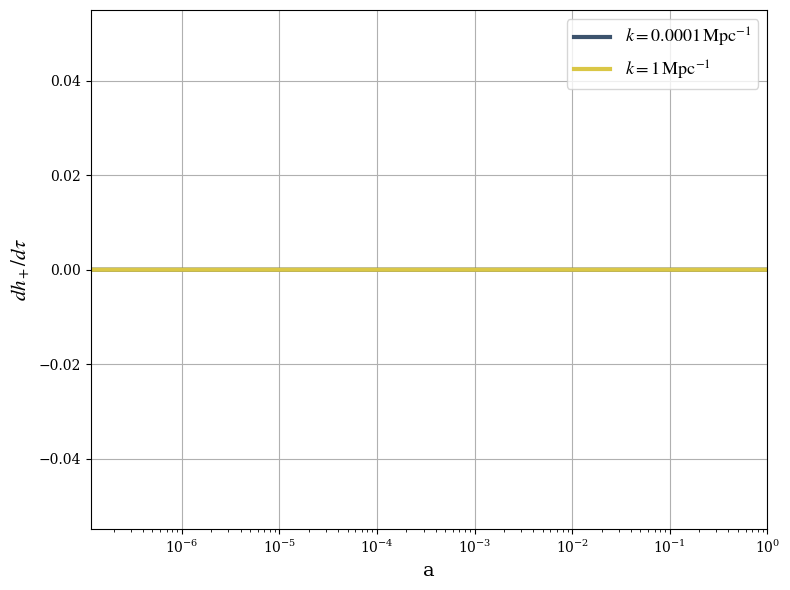

In [13]:
plt.figure(figsize=(8, 6))
for i in range(len(pert)):
    plt.plot(a_k[i], dh_plus[i], color=colors[i % len(colors)], lw=3,
             label=rf'$k = {k_vals[i]:.2g}\,\mathrm{{Mpc}}^{{-1}}$')
plt.xscale('log')
plt.xlabel('a', size=14)
plt.ylabel(r'$d h_+/d\tau$', size=15)
plt.xlim(min(a_k[0]), 1.e0)
plt.legend(fontsize=13)
plt.grid()
plt.tight_layout()

# scalar quantities per k mode (reuse `pert` loaded above)
eta_k       = [p[:, 14] for p in pert]
delta_cdm_k = [p[:, 22] for p in pert]
delta_vf_k  = [p[:, 24] for p in pert]
theta_vf_k  = [p[:, 25] for p in pert]

In [18]:
import glob, re

# pick which native-binary run to load: 'one_k' or 'one_k_tensor'
run = 'one_k'
prefix = f'../../output/{run}_00'

def load_pert(prefix):
    files = sorted(
        glob.glob(f'{prefix}_perturbations_k*_s.dat'),
        key=lambda p: int(re.search(r'_k(\d+)_s', p).group(1)),
    )
    data = [np.loadtxt(f) for f in files]
    ks = []
    for f in files:
        with open(f) as fh:
            ks.append(float(re.search(r'k\s*=\s*([\d.eE+-]+)', fh.readline()).group(1)))
    return data, ks

pert, k_vals = load_pert(prefix)
a_k      = [p[:, 1]  for p in pert]

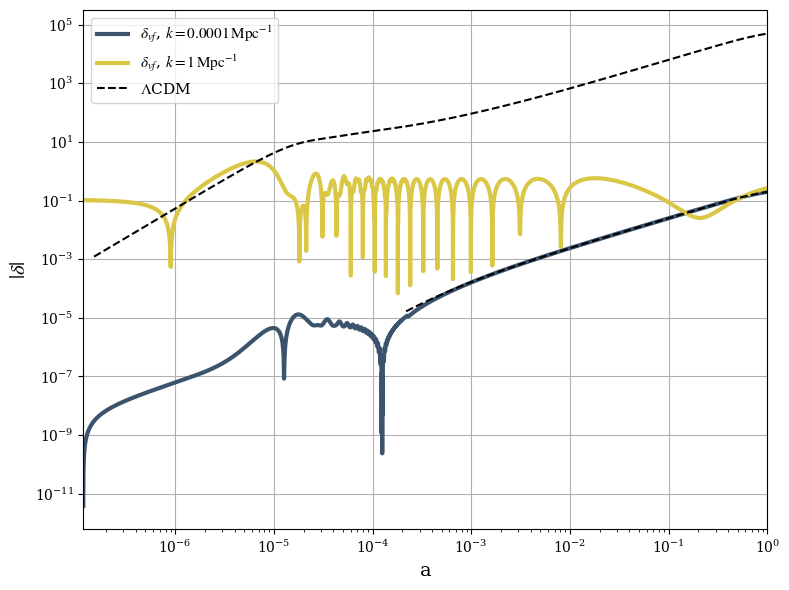

In [19]:
delta_vf_k  = [p[:, 24] for p in pert]
delta_cdm_k = [p[:, 22] for p in pert]
delta_cdm_lcdm = [p[:, 22] for p in pert_lcdm]

plt.figure(figsize=(8, 6))
for i in range(len(pert)):
    plt.loglog(a_k[i], np.abs(delta_vf_k[i]), color=colors[i % len(colors)], lw=3,
               label=rf'$\delta_{{vf}}$, $k = {k_vals[i]:.2g}\,\mathrm{{Mpc}}^{{-1}}$')
for i in range(len(pert_lcdm)):
    plt.loglog(a_k_lcdm[i], np.abs(delta_cdm_lcdm[i]), 'k--', lw=1.5,
               label=r'$\Lambda$CDM' if i == 0 else None)
plt.xlabel('a', size=14)
plt.ylabel(r'$|\delta|$', size=15)
plt.xlim(min(a_k[0]), 1.e0)
plt.legend(fontsize=11)
plt.grid()
plt.tight_layout()

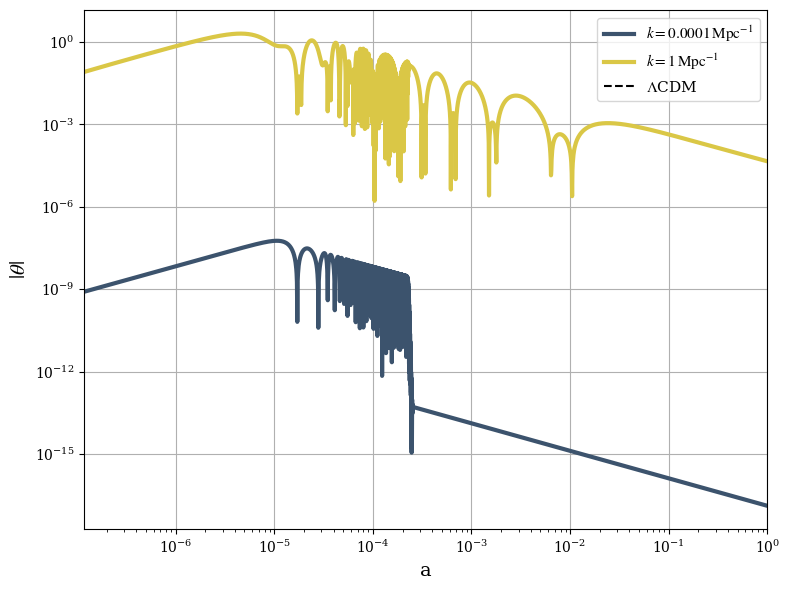

In [20]:
theta_vf_k     = [p[:, 25] for p in pert]
theta_cdm_lcdm = [p[:, 23] for p in pert_lcdm]

plt.figure(figsize=(8, 6))
for i in range(len(pert)):
    plt.loglog(a_k[i], np.abs(theta_vf_k[i]), color=colors[i % len(colors)], lw=3,
               label=rf'$k = {k_vals[i]:.2g}\,\mathrm{{Mpc}}^{{-1}}$')
for i in range(len(pert_lcdm)):
    plt.loglog(a_k_lcdm[i], np.abs(theta_cdm_lcdm[i]), 'k--', lw=1.5,
               label=r'$\Lambda$CDM' if i == 0 else None)
plt.xlabel('a', size=14)
plt.ylabel(r'$|\theta|$', size=15)
plt.xlim(min(a_k[0]), 1.e0)
plt.legend(fontsize=11)
plt.grid()
plt.tight_layout()

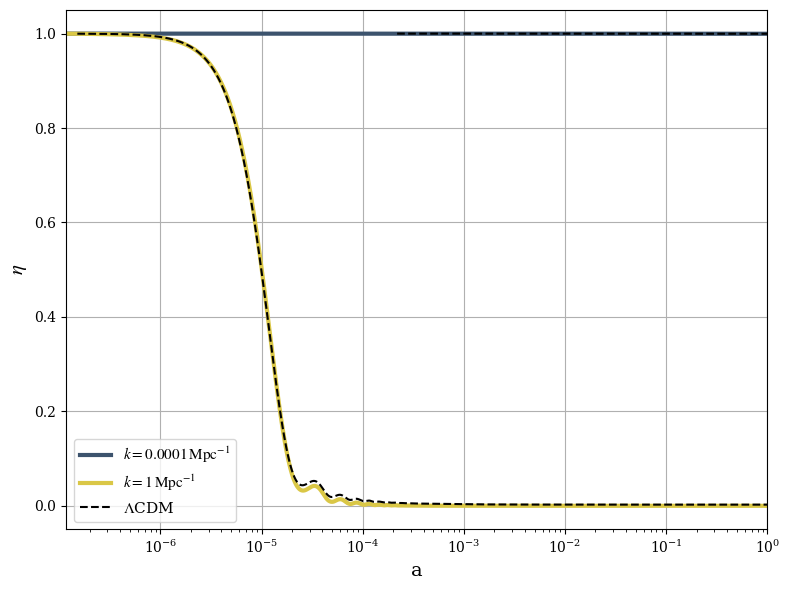

In [21]:
eta_k      = [p[:, 14] for p in pert]
eta_k_lcdm = [p[:, 14] for p in pert_lcdm]

plt.figure(figsize=(8, 6))
for i in range(len(pert)):
    plt.plot(a_k[i], eta_k[i], color=colors[i % len(colors)], lw=3,
             label=rf'$k = {k_vals[i]:.2g}\,\mathrm{{Mpc}}^{{-1}}$')
for i in range(len(pert_lcdm)):
    plt.plot(a_k_lcdm[i], eta_k_lcdm[i], 'k--', lw=1.5,
             label=r'$\Lambda$CDM' if i == 0 else None)
plt.xscale('log')
plt.xlabel('a', size=14)
plt.ylabel(r'$\eta$', size=15)
plt.xlim(min(a_k[0]), 1.e0)
plt.legend(fontsize=11)
plt.grid()
plt.tight_layout()